In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Load all three datasets
lfs = pd.read_parquet('../data/processed/lfs_clean.parquet')
cpi = pd.read_parquet('../data/processed/cpi_clean.parquet')
wages = pd.read_parquet('../data/processed/wages_clean.parquet')

# Set consistent chart style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('colorblind')

print("All datasets loaded")
print(f"LFS: {len(lfs):,} rows")
print(f"CPI: {len(cpi)} rows")
print(f"Wages: {len(wages)} rows")

All datasets loaded
LFS: 6,759,638 rows
CPI: 192 rows
Wages: 1235 rows


## Question 1 — How did employment rates differ by province 2021–2026?

We calculate the monthly employment rate for each province
as: employed / (employed + unemployed) × 100.
We exclude people not in the labour force from the denominator
because they are neither employed nor looking for work.

In [2]:
# Filter to labour force only (employed + unemployed)
in_lf = lfs[lfs['LFSSTAT'].isin([1, 2])]

# Calculate monthly employment rate by province
prov_monthly = in_lf.groupby(['date', 'prov_label']).agg(
    employed=('is_employed', 'sum'),
    total_lf=('is_employed', 'count')
).reset_index()

prov_monthly['emp_rate'] = (prov_monthly['employed'] / prov_monthly['total_lf'] * 100).round(2)

print("Sample output:")
print(prov_monthly.head(10))

Sample output:
        date        prov_label  employed  total_lf  emp_rate
0 2021-01-01           Alberta      4479      4922     91.00
1 2021-01-01  British Columbia      4842      5270     91.88
2 2021-01-01          Manitoba      4358      4754     91.67
3 2021-01-01     New Brunswick      2116      2330     90.82
4 2021-01-01      Newfoundland      1185      1333     88.90
5 2021-01-01       Nova Scotia      2079      2257     92.11
6 2021-01-01           Ontario     10583     11794     89.73
7 2021-01-01               PEI      1266      1395     90.75
8 2021-01-01            Quebec      7456      8368     89.10
9 2021-01-01      Saskatchewan      3036      3273     92.76


### Chart 1 — Provincial Employment Rate Over Time

Showing all 10 provinces on one chart to identify
which provinces recovered fastest after 2021 and
which are still lagging as of April 2026.

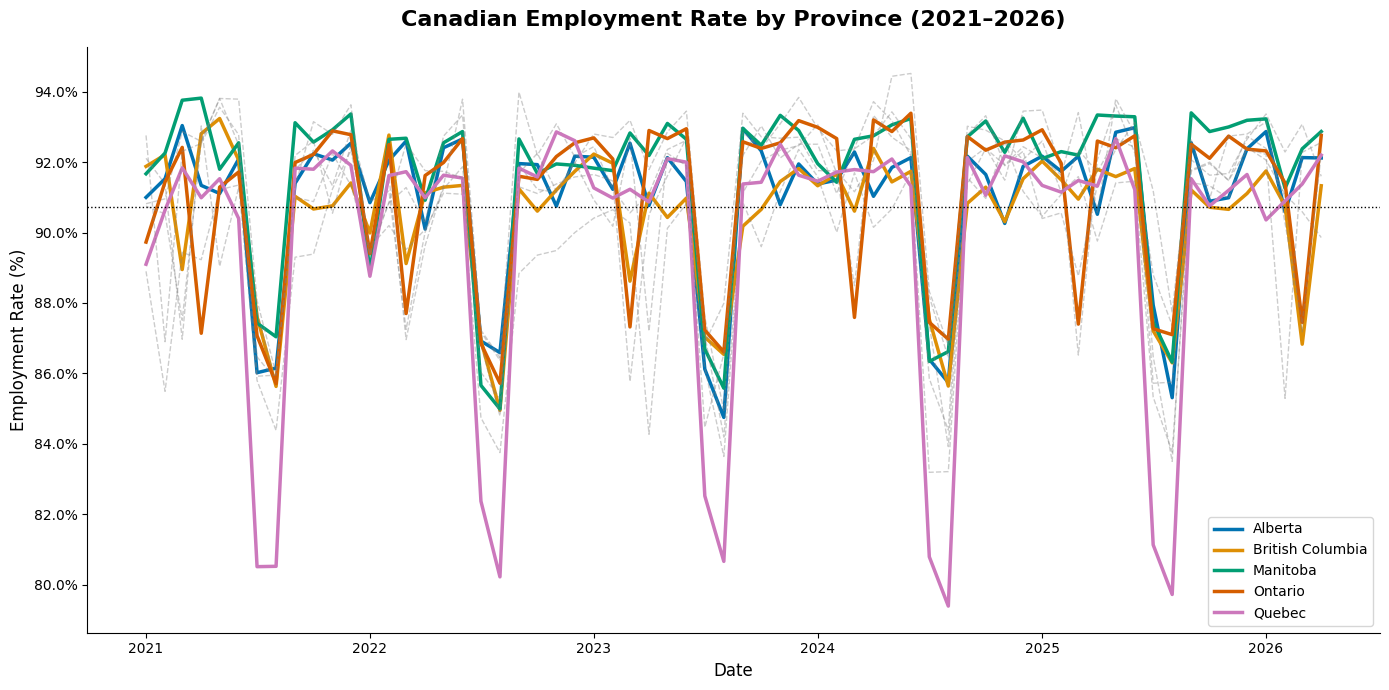

Chart saved!


In [3]:
fig, ax = plt.subplots(figsize=(14, 7))

# Get top 5 largest provinces for highlighted lines
big_provs = ['Ontario', 'British Columbia', 'Alberta', 'Quebec', 'Manitoba']

for prov in prov_monthly['prov_label'].unique():
    data = prov_monthly[prov_monthly['prov_label'] == prov]
    if prov in big_provs:
        ax.plot(data['date'], data['emp_rate'], linewidth=2.5, label=prov)
    else:
        ax.plot(data['date'], data['emp_rate'], linewidth=1, 
                alpha=0.4, color='grey', linestyle='--')

ax.set_title("Canadian Employment Rate by Province (2021–2026)", 
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Employment Rate (%)", fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(loc='lower right', fontsize=10)
ax.axhline(y=prov_monthly['emp_rate'].mean(), color='black', 
           linestyle=':', linewidth=1, label='National average')

plt.tight_layout()
plt.savefig('../docs/chart1_provincial_employment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

### Chart 2 — Province Comparison: Average Employment Rate 2021 vs 2025

A cleaner bar chart showing which provinces improved most
between 2021 and 2025 — directly answers the interview question
"what was your key finding?"

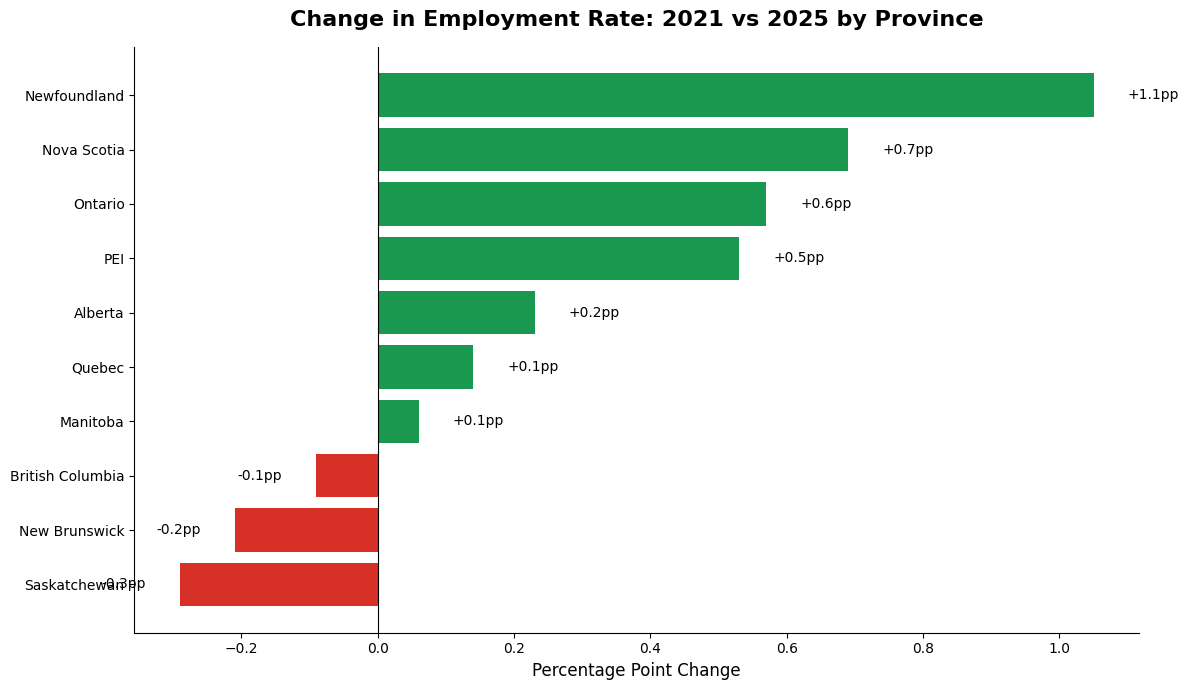

Chart saved!


In [4]:
# Average employment rate per province for 2021 vs 2025
prov_yearly = in_lf.groupby(['year', 'prov_label']).agg(
    employed=('is_employed', 'sum'),
    total_lf=('is_employed', 'count')
).reset_index()

prov_yearly['emp_rate'] = (prov_yearly['employed'] / prov_yearly['total_lf'] * 100).round(2)

# Keep only 2021 and 2025
compare = prov_yearly[prov_yearly['year'].isin([2021, 2025])]

# Pivot for easy plotting
pivot = compare.pivot(index='prov_label', columns='year', values='emp_rate')
pivot['change'] = pivot[2025] - pivot[2021]
pivot = pivot.sort_values('change', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))

colors = ['#d73027' if x < 0 else '#1a9850' for x in pivot['change']]
bars = ax.barh(pivot.index, pivot['change'], color=colors)

ax.set_title("Change in Employment Rate: 2021 vs 2025 by Province", 
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Percentage Point Change", fontsize=12)
ax.axvline(x=0, color='black', linewidth=0.8)

# Add value labels
for bar, val in zip(bars, pivot['change']):
    ax.text(val + (0.05 if val >= 0 else -0.05), bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}pp', va='center', 
            ha='left' if val >= 0 else 'right', fontsize=10)

plt.tight_layout()
plt.savefig('../docs/chart2_province_change.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

## Question 2 — What happened to full-time vs part-time work 2021–2026?

Part-time work is often involuntary — workers who want full-time
hours but can only find part-time. A rising part-time share signals
labour market weakness even when headline employment looks strong.
We calculate the share of employed people working part-time each month
to see if the quality of employment changed over our period.

In [5]:
# Filter to employed people only
employed = lfs[lfs['LFSSTAT'] == 1].copy()

# Monthly full time vs part time breakdown
ftpt_monthly = employed.groupby(['date', 'ftpt_label']).size().reset_index(name='count')

# Calculate share
ftpt_total = employed.groupby('date').size().reset_index(name='total')
ftpt_monthly = ftpt_monthly.merge(ftpt_total, on='date')
ftpt_monthly['share'] = (ftpt_monthly['count'] / ftpt_monthly['total'] * 100).round(2)

# Keep part-time only for trend line
parttime = ftpt_monthly[ftpt_monthly['ftpt_label'] == 'Part-time'].copy()

print("Part-time share sample:")
print(parttime[['date', 'count', 'total', 'share']].head(10))

Part-time share sample:
         date  count  total  share
1  2021-01-01   7427  41400  17.94
3  2021-02-01   8245  42969  19.19
5  2021-03-01   8557  44334  19.30
7  2021-04-01   8190  44516  18.40
9  2021-05-01   8106  45998  17.62
11 2021-06-01   8384  46642  17.98
13 2021-07-01   7394  42694  17.32
15 2021-08-01   7307  42591  17.16
17 2021-09-01   8465  45805  18.48
19 2021-10-01   8695  46192  18.82


### Chart 3 — Part-time Employment Share Over Time

A rising trend means more workers are stuck in part-time jobs.
We also split by immigrant vs Canadian-born to see if the
burden of part-time work falls unevenly.

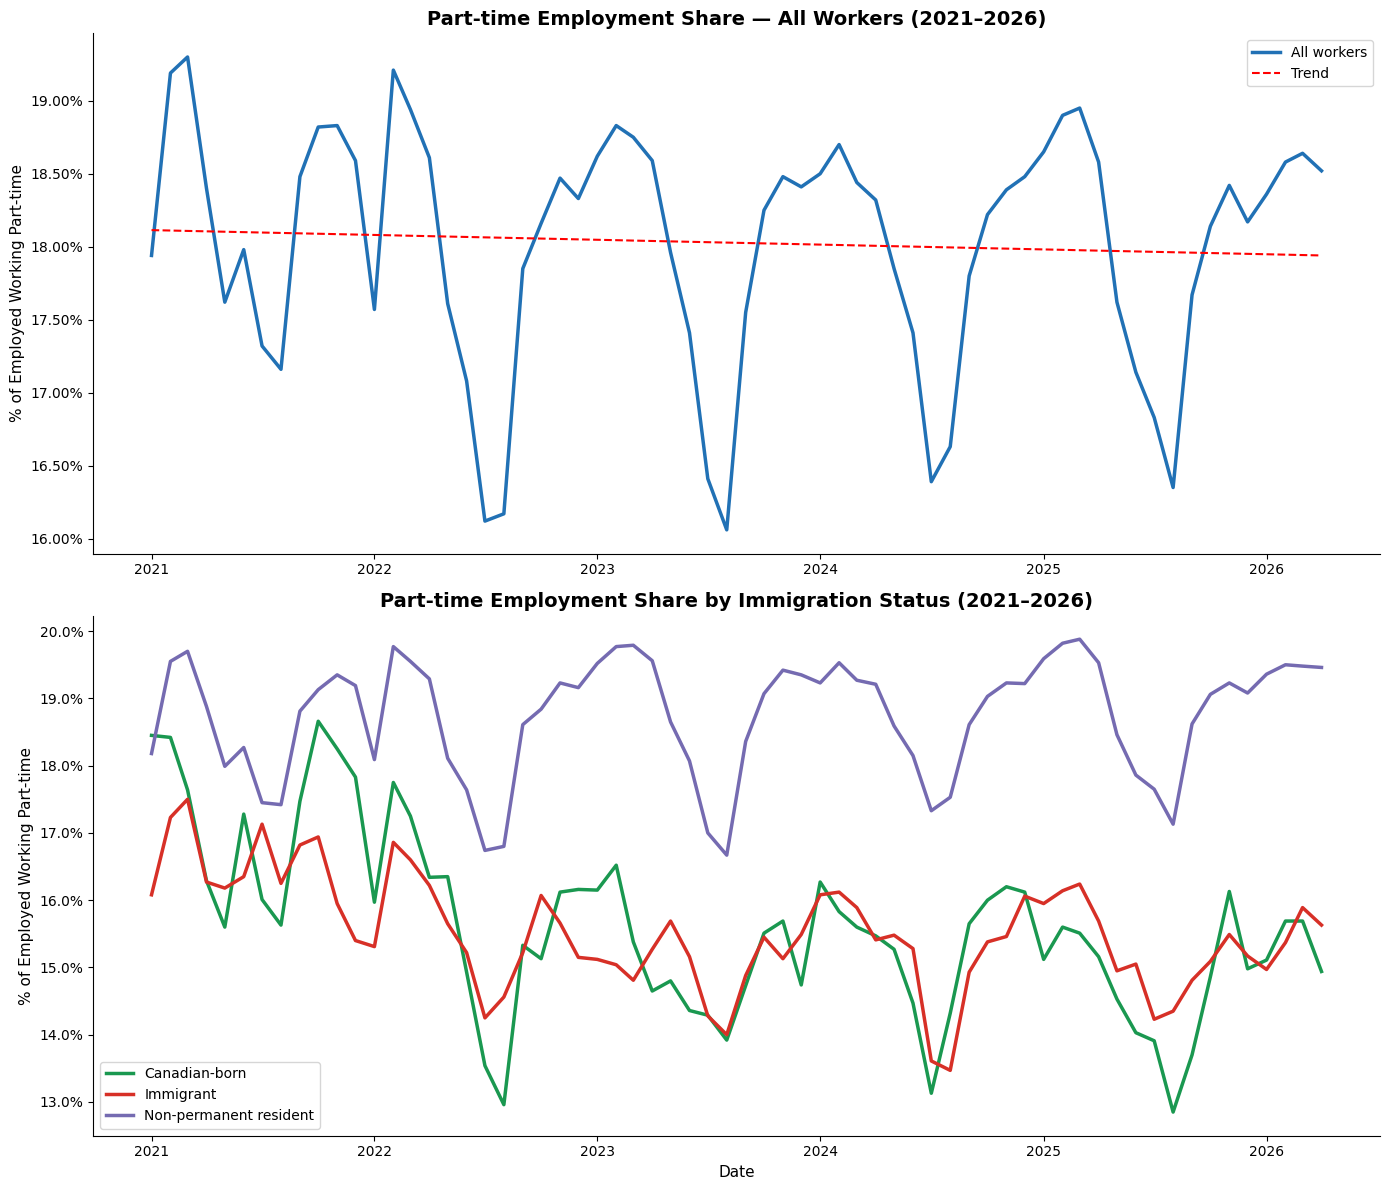

Chart saved!


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# --- Top chart: overall part-time share ---
ax1 = axes[0]
ax1.plot(parttime['date'], parttime['share'], 
         color='#2171b5', linewidth=2.5, label='All workers')

# Add trend line
z = np.polyfit(range(len(parttime)), parttime['share'], 1)
p = np.poly1d(z)
ax1.plot(parttime['date'], p(range(len(parttime))), 
         color='red', linewidth=1.5, linestyle='--', label='Trend')

ax1.set_title("Part-time Employment Share — All Workers (2021–2026)", 
              fontsize=14, fontweight='bold')
ax1.set_ylabel("% of Employed Working Part-time", fontsize=11)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.legend(fontsize=10)

# --- Bottom chart: immigrant vs Canadian-born ---
ax2 = axes[1]

for immig_group, color, label in [
    ('Canadian-born', '#1a9850', 'Canadian-born'),
    ('Immigrant', '#d73027', 'Immigrant'),
    ('Non-permanent resident', '#756bb1', 'Non-permanent resident')
]:
    group_data = employed[employed['immig_label'] == immig_group]
    
    ftpt_group = group_data.groupby(['date', 'ftpt_label']).size().reset_index(name='count')
    total_group = group_data.groupby('date').size().reset_index(name='total')
    ftpt_group = ftpt_group.merge(total_group, on='date')
    ftpt_group['share'] = (ftpt_group['count'] / ftpt_group['total'] * 100).round(2)
    
    pt_group = ftpt_group[ftpt_group['ftpt_label'] == 'Part-time']
    ax2.plot(pt_group['date'], pt_group['share'], 
             color=color, linewidth=2.5, label=label)

ax2.set_title("Part-time Employment Share by Immigration Status (2021–2026)", 
              fontsize=14, fontweight='bold')
ax2.set_ylabel("% of Employed Working Part-time", fontsize=11)
ax2.set_xlabel("Date", fontsize=11)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../docs/chart3_parttime_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

### Chart 4 — Part-time Share by Education Level

Does higher education protect workers from part-time employment?
This connects our labour market analysis to the broader
debate about the value of post-secondary education in Canada.

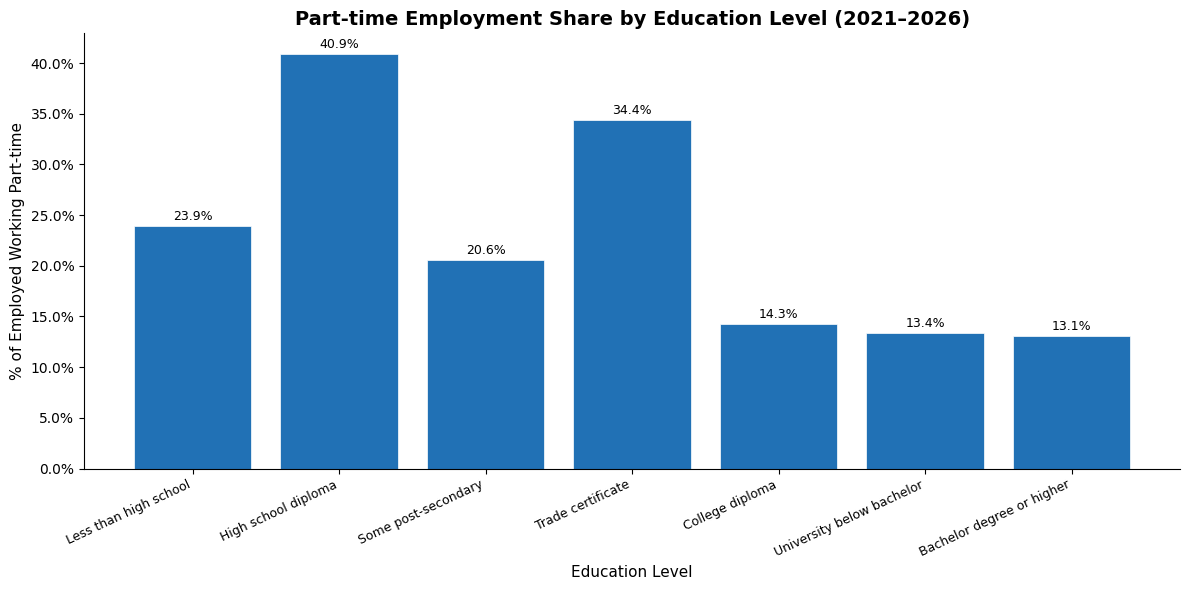

Chart saved!


In [7]:
# Part-time share by education — averaged across full period
educ_ftpt = employed.groupby(['educ_label', 'ftpt_label']).size().reset_index(name='count')
educ_total = employed.groupby('educ_label').size().reset_index(name='total')
educ_ftpt = educ_ftpt.merge(educ_total, on='educ_label')
educ_ftpt['share'] = (educ_ftpt['count'] / educ_ftpt['total'] * 100).round(2)

pt_educ = educ_ftpt[educ_ftpt['ftpt_label'] == 'Part-time'].copy()

# Sort by education level logically
educ_order = [
    'Less than high school', 'High school diploma', 'Some post-secondary',
    'Trade certificate', 'College diploma', 
    'University below bachelor', 'Bachelor degree or higher'
]
pt_educ['educ_label'] = pd.Categorical(pt_educ['educ_label'], 
                                        categories=educ_order, ordered=True)
pt_educ = pt_educ.sort_values('educ_label')

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(pt_educ['educ_label'], pt_educ['share'], 
              color='#2171b5', edgecolor='white', linewidth=0.5)

ax.set_title("Part-time Employment Share by Education Level (2021–2026)", 
             fontsize=14, fontweight='bold')
ax.set_ylabel("% of Employed Working Part-time", fontsize=11)
ax.set_xlabel("Education Level", fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.xticks(rotation=25, ha='right', fontsize=9)

# Add value labels on bars
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../docs/chart4_parttime_education.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

## Question 3 — Which industries recovered fastest and did wages keep up with inflation?

We combine LFS employment data with Statistics Canada wage data
and CPI to calculate real wages — wages adjusted for inflation.
A industry can show strong employment recovery but declining
real wages, meaning workers are employed but worse off financially.
This is the core "who got left behind" question of our project.

In [8]:
# Employment by industry over time
# Filter to employed people with valid industry codes
employed_industry = lfs[
    (lfs['LFSSTAT'] == 1) & 
    (lfs['NAICS_21'].notna())
].copy()

# NAICS industry codes from LFS codebook
naics_map = {
    1:  'Agriculture',
    2:  'Forestry & Mining',
    3:  'Utilities',
    4:  'Construction',
    5:  'Manufacturing',
    6:  'Wholesale trade',
    7:  'Retail trade',
    8:  'Transport & Warehousing',
    9:  'Finance & Real Estate',
    10: 'Professional Services',
    11: 'Business Services',
    12: 'Education',
    13: 'Healthcare',
    14: 'Information & Culture',
    15: 'Accommodation & Food',
    16: 'Other Services',
    17: 'Public Administration'
}

employed_industry['industry_label'] = employed_industry['NAICS_21'].map(naics_map)

# Monthly employment count by industry
industry_monthly = employed_industry.groupby(
    ['date', 'industry_label']
).size().reset_index(name='employed_count')

print("Industries found:")
print(employed_industry['industry_label'].value_counts())

Industries found:
industry_label
Public Administration      517857
Professional Services      399563
Wholesale trade            283167
Information & Culture      277312
Other Services             270178
Business Services          185030
Retail trade               165712
Education                  155619
Transport & Warehousing    146305
Accommodation & Food       120739
Finance & Real Estate      116192
Agriculture                 64847
Construction                64324
Healthcare                  62388
Manufacturing               31008
Forestry & Mining           11716
Utilities                    5638
Name: count, dtype: int64


### Chart 5 — Industry Employment Recovery Index

We index all industries to January 2021 = 100 so we can
compare recovery trajectories regardless of industry size.
An index above 100 means the industry has more employed
workers than at the start of our period.

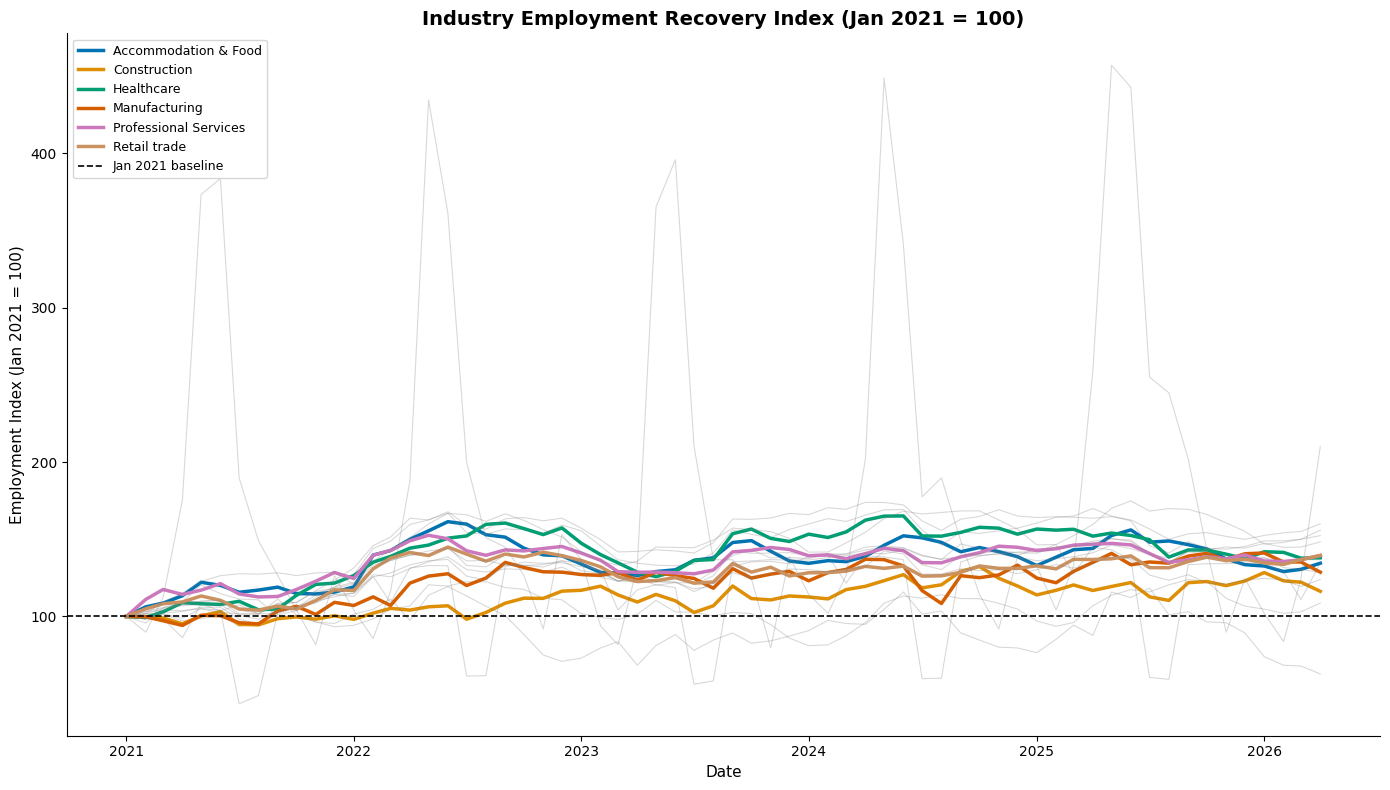

Chart saved!


In [9]:
# Calculate index: Jan 2021 = 100 for each industry
base_date = pd.Timestamp('2021-01-01')

# Get baseline values
baseline = industry_monthly[industry_monthly['date'] == base_date][
    ['industry_label', 'employed_count']
].rename(columns={'employed_count': 'base_count'})

industry_indexed = industry_monthly.merge(baseline, on='industry_label')
industry_indexed['index'] = (
    industry_indexed['employed_count'] / industry_indexed['base_count'] * 100
).round(2)

# Pick most interesting industries to highlight
highlight = [
    'Accommodation & Food', 
    'Healthcare',
    'Professional Services',
    'Retail trade',
    'Construction',
    'Manufacturing'
]

fig, ax = plt.subplots(figsize=(14, 8))

for industry in industry_indexed['industry_label'].unique():
    data = industry_indexed[industry_indexed['industry_label'] == industry]
    if industry in highlight:
        ax.plot(data['date'], data['index'], linewidth=2.5, label=industry)
    else:
        ax.plot(data['date'], data['index'], linewidth=0.8, 
                alpha=0.3, color='grey')

# Baseline reference line
ax.axhline(y=100, color='black', linewidth=1.2, 
           linestyle='--', label='Jan 2021 baseline')

ax.set_title("Industry Employment Recovery Index (Jan 2021 = 100)", 
             fontsize=14, fontweight='bold')
ax.set_ylabel("Employment Index (Jan 2021 = 100)", fontsize=11)
ax.set_xlabel("Date", fontsize=11)
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('../docs/chart5_industry_recovery.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

### Chart 6 — Real Wage Growth by Industry 2021–2026

Combining Statistics Canada average hourly wages with CPI
to calculate real wage growth — the actual change in purchasing
power for workers in each industry after accounting for inflation.
Negative real wage growth means workers earned more dollars
but could buy less with them.

In [10]:
# Set Jan 2021 as CPI base
cpi_base = cpi[cpi['date'] == pd.Timestamp('2021-01-01')]['cpi_value'].values[0]

cpi['cpi_index'] = (cpi['cpi_value'] / cpi_base * 100).round(4)

# Get Jan 2021 and latest wages per industry
wages['date'] = pd.to_datetime(wages['date'])

wages_2021 = wages[wages['date'] == pd.Timestamp('2021-01-01')][
    ['industry', 'avg_hourly_wage']
].rename(columns={'avg_hourly_wage': 'wage_2021'})

wages_2026 = wages[wages['date'] == pd.Timestamp('2026-04-01')][
    ['industry', 'avg_hourly_wage']
].rename(columns={'avg_hourly_wage': 'wage_2026'})

wage_compare = wages_2021.merge(wages_2026, on='industry')

# Get CPI values for same dates
cpi_2021 = cpi[cpi['date'] == pd.Timestamp('2021-01-01')]['cpi_value'].values[0]
cpi_2026 = cpi[cpi['date'] == pd.Timestamp('2026-04-01')]['cpi_value'].values[0]

# Nominal wage change
wage_compare['nominal_change_pct'] = (
    (wage_compare['wage_2026'] - wage_compare['wage_2021']) / 
    wage_compare['wage_2021'] * 100
).round(2)

# Inflation over period
inflation_pct = ((cpi_2026 - cpi_2021) / cpi_2021 * 100).round(2)

# Real wage change = nominal change minus inflation
wage_compare['real_change_pct'] = (
    wage_compare['nominal_change_pct'] - inflation_pct
).round(2)

print(f"Inflation Jan 2021 → Apr 2026: {inflation_pct:.1f}%")
print("\nReal wage change by industry:")
print(wage_compare[['industry', 'wage_2021', 'wage_2026', 
                     'nominal_change_pct', 'real_change_pct']]
      .sort_values('real_change_pct', ascending=False).to_string())

Inflation Jan 2021 → Apr 2026: 21.6%

Real wage change by industry:
                                                   industry  wage_2021  wage_2026  nominal_change_pct  real_change_pct
11          Professional, scientific and technical services      37.63      50.49               34.17            12.61
6                                             Manufacturing      28.93      36.75               27.03             5.47
10      Finance, insurance, real estate, rental and leasing      37.13      47.11               26.88             5.32
2                                            Agriculture 10      20.84      26.30               26.20             4.64
17            Other services (except public administration)      26.69      33.43               25.25             3.69
16                          Accommodation and food services      17.27      21.48               24.38             2.82
1                                  Goods-producing sector 9      31.66      39.37               24.

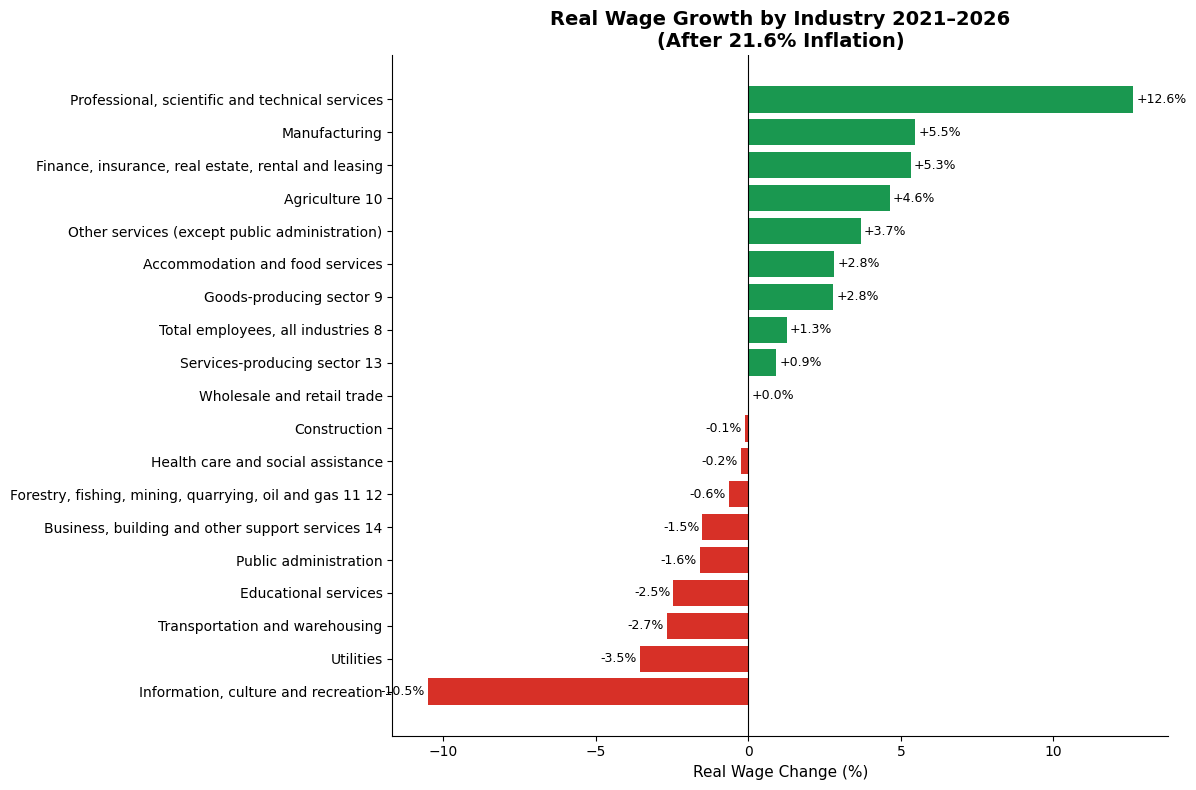

Chart saved!


In [11]:
# Plot real wage changes
wage_plot = wage_compare.sort_values('real_change_pct', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#d73027' if x < 0 else '#1a9850' for x in wage_plot['real_change_pct']]
bars = ax.barh(wage_plot['industry'], wage_plot['real_change_pct'], color=colors)

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title(f"Real Wage Growth by Industry 2021–2026\n(After {inflation_pct:.1f}% Inflation)", 
             fontsize=14, fontweight='bold')
ax.set_xlabel("Real Wage Change (%)", fontsize=11)

# Value labels
for bar, val in zip(bars, wage_plot['real_change_pct']):
    ax.text(val + (0.1 if val >= 0 else -0.1), 
            bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}%', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('../docs/chart6_real_wages.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

## Question 4 — Did immigrant workers recover at the same rate as Canadian-born workers?

Immigration is one of Canada's most debated economic topics.
Canada admitted record numbers of immigrants between 2021–2024.
We examine whether employment outcomes for immigrants kept pace
with Canadian-born workers, and whether education level
changed the gap — a question directly relevant to immigration
and labour market policy.

In [12]:
# Monthly employment rate by immigration status
in_lf = lfs[lfs['LFSSTAT'].isin([1, 2])].copy()

immig_monthly = in_lf.groupby(['date', 'immig_label']).agg(
    employed=('is_employed', 'sum'),
    total_lf=('is_employed', 'count')
).reset_index()

immig_monthly['emp_rate'] = (
    immig_monthly['employed'] / immig_monthly['total_lf'] * 100
).round(2)

print("Sample:")
print(immig_monthly.head(9))

Sample:
        date             immig_label  employed  total_lf  emp_rate
0 2021-01-01           Canadian-born      2428      2635     92.14
1 2021-01-01               Immigrant      5080      5618     90.42
2 2021-01-01  Non-permanent resident     33892     37443     90.52
3 2021-02-01           Canadian-born      2589      2786     92.93
4 2021-02-01               Immigrant      5455      5925     92.07
5 2021-02-01  Non-permanent resident     34925     38534     90.63
6 2021-03-01           Canadian-born      2607      2810     92.78
7 2021-03-01               Immigrant      5629      6075     92.66
8 2021-03-01  Non-permanent resident     36098     39497     91.39


### Chart 7 — Employment Rate Gap: Immigrants vs Canadian-born

The gap between immigrant and Canadian-born employment rates
tells us whether labour market integration improved or worsened
over our period. A narrowing gap means better integration.
A widening gap means immigrants are being left behind.

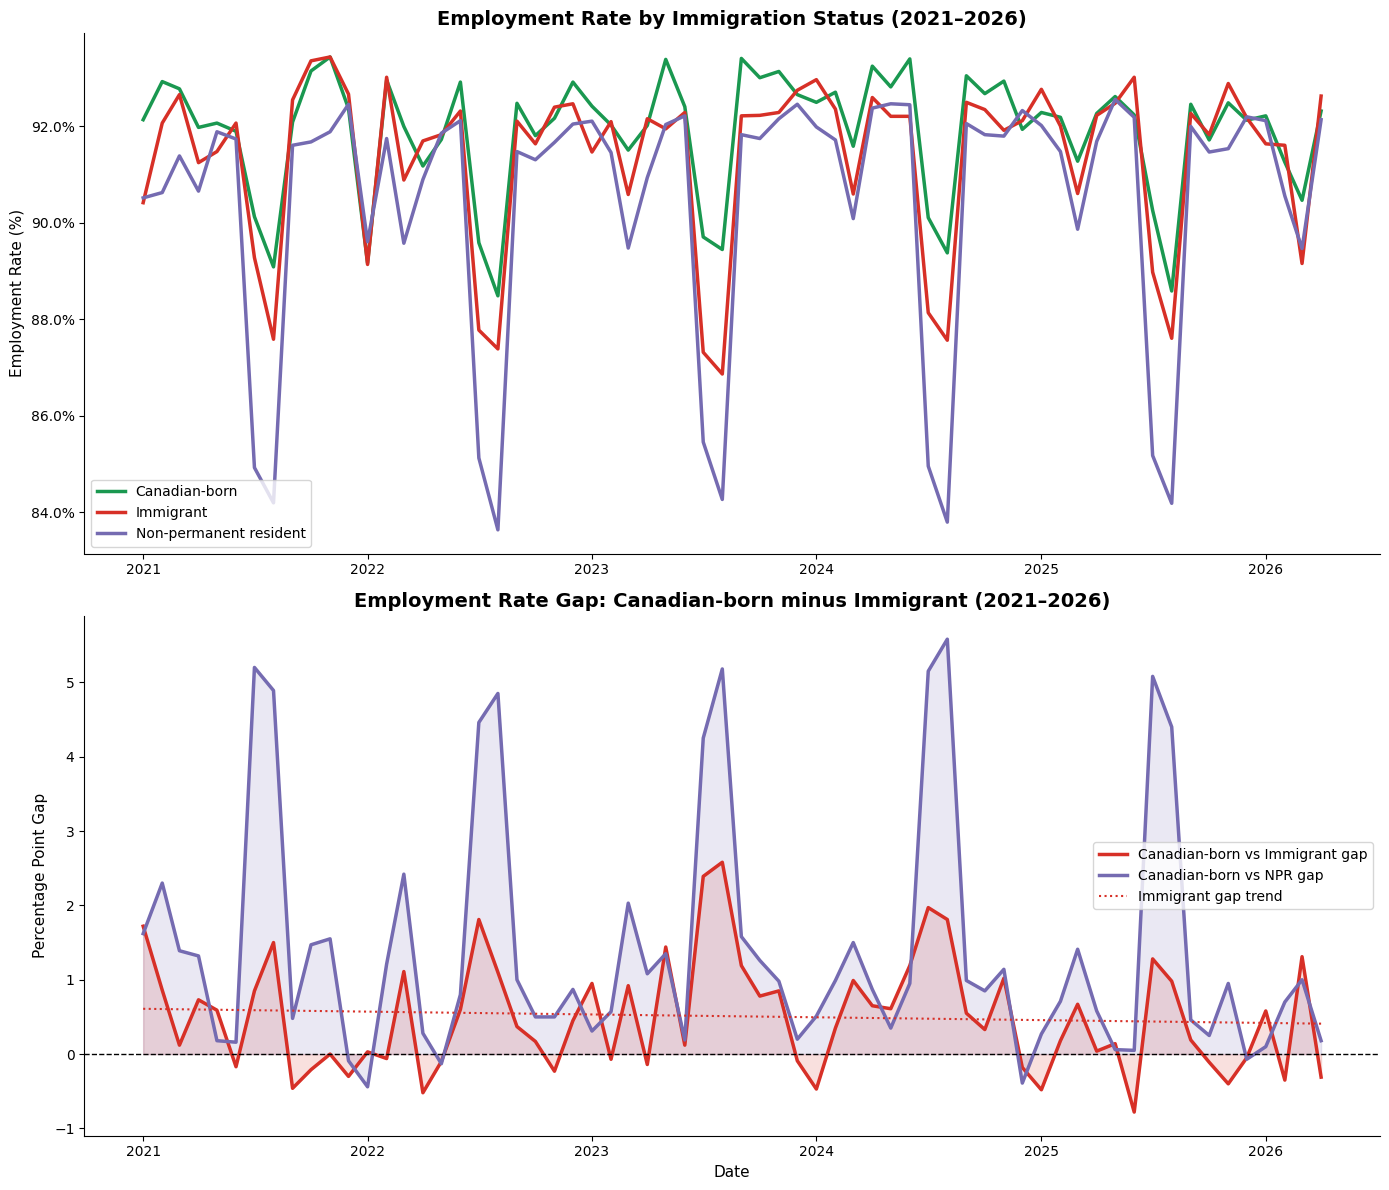

Chart saved!


In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# --- Top chart: employment rate by immigration status ---
ax1 = axes[0]

colors = {
    'Canadian-born': '#1a9850',
    'Immigrant': '#d73027',
    'Non-permanent resident': '#756bb1'
}

for group, color in colors.items():
    data = immig_monthly[immig_monthly['immig_label'] == group]
    ax1.plot(data['date'], data['emp_rate'],
             color=color, linewidth=2.5, label=group)

ax1.set_title("Employment Rate by Immigration Status (2021–2026)",
              fontsize=14, fontweight='bold')
ax1.set_ylabel("Employment Rate (%)", fontsize=11)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.legend(fontsize=10)

# --- Bottom chart: the gap itself ---
ax2 = axes[1]

# Pivot to calculate gap
immig_pivot = immig_monthly.pivot(
    index='date', columns='immig_label', values='emp_rate'
).reset_index()

# Gap = Canadian-born minus immigrant
immig_pivot['gap_immigrant'] = (
    immig_pivot['Canadian-born'] - immig_pivot['Immigrant']
).round(2)
immig_pivot['gap_npr'] = (
    immig_pivot['Canadian-born'] - immig_pivot['Non-permanent resident']
).round(2)

ax2.plot(immig_pivot['date'], immig_pivot['gap_immigrant'],
         color='#d73027', linewidth=2.5, label='Canadian-born vs Immigrant gap')
ax2.plot(immig_pivot['date'], immig_pivot['gap_npr'],
         color='#756bb1', linewidth=2.5, label='Canadian-born vs NPR gap')

ax2.axhline(y=0, color='black', linewidth=1, linestyle='--')
ax2.fill_between(immig_pivot['date'], immig_pivot['gap_immigrant'],
                 0, alpha=0.15, color='#d73027')
ax2.fill_between(immig_pivot['date'], immig_pivot['gap_npr'],
                 0, alpha=0.15, color='#756bb1')

# Trend line for immigrant gap
z = np.polyfit(range(len(immig_pivot)), immig_pivot['gap_immigrant'], 1)
p = np.poly1d(z)
ax2.plot(immig_pivot['date'], p(range(len(immig_pivot))),
         color='#d73027', linewidth=1.5, linestyle=':', label='Immigrant gap trend')

ax2.set_title("Employment Rate Gap: Canadian-born minus Immigrant (2021–2026)",
              fontsize=14, fontweight='bold')
ax2.set_ylabel("Percentage Point Gap", fontsize=11)
ax2.set_xlabel("Date", fontsize=11)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../docs/chart7_immigrant_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

### Chart 8 — Immigrant Employment Gap by Education Level

Does higher education close the immigrant employment gap?
If immigrants with degrees have the same employment rate as
Canadian-born degree holders, education is the equaliser.
If a gap persists even at the highest education levels,
it suggests structural barriers beyond qualifications.

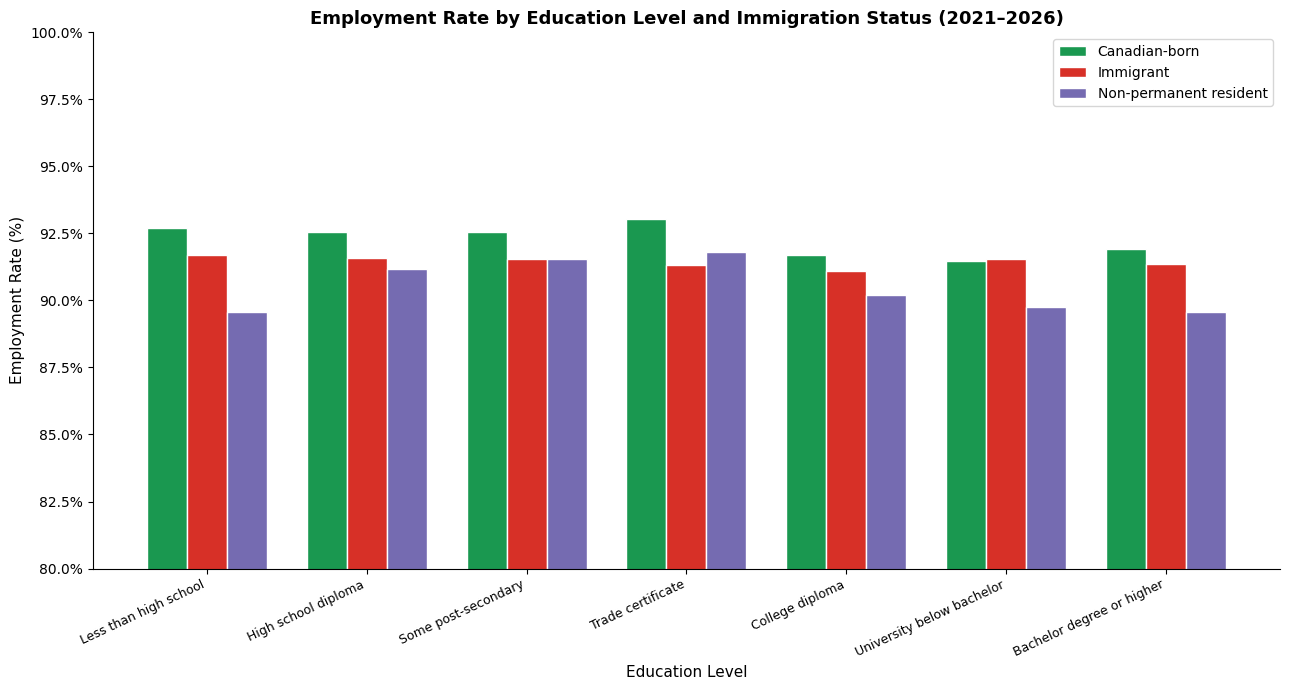

Chart saved!


In [14]:
# Employment rate by immigration status AND education level
# Average across full period
educ_immig = in_lf.groupby(['educ_label', 'immig_label']).agg(
    employed=('is_employed', 'sum'),
    total_lf=('is_employed', 'count')
).reset_index()

educ_immig['emp_rate'] = (
    educ_immig['employed'] / educ_immig['total_lf'] * 100
).round(2)

# Order education levels
educ_order = [
    'Less than high school', 'High school diploma', 'Some post-secondary',
    'Trade certificate', 'College diploma',
    'University below bachelor', 'Bachelor degree or higher'
]

educ_immig['educ_label'] = pd.Categorical(
    educ_immig['educ_label'], categories=educ_order, ordered=True
)
educ_immig = educ_immig.sort_values('educ_label')

fig, ax = plt.subplots(figsize=(13, 7))

bar_width = 0.25
x = range(len(educ_order))

for i, (group, color) in enumerate(colors.items()):
    data = educ_immig[educ_immig['immig_label'] == group]
    offset = (i - 1) * bar_width
    bars = ax.bar(
        [xi + offset for xi in x],
        data['emp_rate'],
        width=bar_width,
        color=color,
        label=group,
        edgecolor='white'
    )

ax.set_title("Employment Rate by Education Level and Immigration Status (2021–2026)",
             fontsize=13, fontweight='bold')
ax.set_ylabel("Employment Rate (%)", fontsize=11)
ax.set_xlabel("Education Level", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(educ_order, rotation=25, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=10)
ax.set_ylim(80, 100)

plt.tight_layout()
plt.savefig('../docs/chart8_immigrant_education_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

## Summary of Key Findings

1. **Provincial recovery was uneven** — Newfoundland improved most (+1.1pp) 
   while Saskatchewan declined (-0.3pp). Quebec shows persistent 
   seasonal employment dips every summer.

2. **Part-time work declined slightly overall** but non-permanent residents 
   consistently work part-time at rates 3–4pp above Canadian-born and 
   immigrant workers throughout 2021–2026.

3. **Real wages diverged sharply by industry** — after 21.6% cumulative 
   inflation, professional services workers gained +12.6% in real terms 
   while information & culture workers lost -10.5%. Healthcare and 
   education workers also fell behind inflation.

4. **The immigrant employment gap is small but persistent** — roughly 1pp 
   across all education levels, suggesting structural barriers beyond 
   qualifications. Record immigration did not widen or narrow the gap.

In [15]:
# Save the monthly employment baseline for Power BI
monthly_emp = in_lf.groupby('date').agg(
    employed=('is_employed', 'sum'),
    total_lf=('is_employed', 'count')
).reset_index()
monthly_emp['emp_rate'] = (monthly_emp['employed'] / monthly_emp['total_lf'] * 100).round(2)

# Save all summary tables for Power BI
prov_monthly.to_csv('../data/processed/prov_monthly.csv', index=False)
monthly_emp.to_csv('../data/processed/national_monthly.csv', index=False)
immig_monthly.to_csv('../data/processed/immig_monthly.csv', index=False)
industry_indexed.to_csv('../data/processed/industry_indexed.csv', index=False)
wage_compare.to_csv('../data/processed/wage_compare.csv', index=False)

print("All summary tables saved for Power BI!")
print("\nFiles saved:")
print("  prov_monthly.csv — provincial employment rates")
print("  national_monthly.csv — overall employment rate")
print("  immig_monthly.csv — employment by immigration status")
print("  industry_indexed.csv — industry recovery index")
print("  wage_compare.csv — real wage changes by industry")

All summary tables saved for Power BI!

Files saved:
  prov_monthly.csv — provincial employment rates
  national_monthly.csv — overall employment rate
  immig_monthly.csv — employment by immigration status
  industry_indexed.csv — industry recovery index
  wage_compare.csv — real wage changes by industry


## Summary of Key Findings

1. **Provincial recovery was uneven** — Newfoundland improved most (+1.1pp) 
   while Saskatchewan declined (-0.3pp). Quebec shows persistent 
   seasonal employment dips every summer.

2. **Part-time work declined slightly overall** but non-permanent residents 
   consistently work part-time at rates 3–4pp above Canadian-born and 
   immigrant workers throughout 2021–2026.

3. **Real wages diverged sharply by industry** — after 21.6% cumulative 
   inflation, professional services workers gained +12.6% in real terms 
   while information & culture workers lost -10.5%. Healthcare and 
   education workers also fell behind inflation.

4. **The immigrant employment gap is small but persistent** — roughly 1pp 
   across all education levels, suggesting structural barriers beyond 
   qualifications. Record immigration did not widen or narrow the gap.

In [16]:
# Save the monthly employment baseline for Power BI
monthly_emp = in_lf.groupby('date').agg(
    employed=('is_employed', 'sum'),
    total_lf=('is_employed', 'count')
).reset_index()
monthly_emp['emp_rate'] = (monthly_emp['employed'] / monthly_emp['total_lf'] * 100).round(2)

# Save all summary tables for Power BI
prov_monthly.to_csv('../data/processed/prov_monthly.csv', index=False)
monthly_emp.to_csv('../data/processed/national_monthly.csv', index=False)
immig_monthly.to_csv('../data/processed/immig_monthly.csv', index=False)
industry_indexed.to_csv('../data/processed/industry_indexed.csv', index=False)
wage_compare.to_csv('../data/processed/wage_compare.csv', index=False)

print("All summary tables saved for Power BI!")
print("\nFiles saved:")
print("  prov_monthly.csv — provincial employment rates")
print("  national_monthly.csv — overall employment rate")
print("  immig_monthly.csv — employment by immigration status")
print("  industry_indexed.csv — industry recovery index")
print("  wage_compare.csv — real wage changes by industry")

All summary tables saved for Power BI!

Files saved:
  prov_monthly.csv — provincial employment rates
  national_monthly.csv — overall employment rate
  immig_monthly.csv — employment by immigration status
  industry_indexed.csv — industry recovery index
  wage_compare.csv — real wage changes by industry
